In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [129]:
# Load data and remove duplicates immediately
import seaborn as sns
import pandas as pd
df = sns.load_dataset('titanic')
df = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (784, 15)


In [130]:
# Consolidation of preprocessing to avoid duplicate code blocks
df['age'] = df['age'].fillna(df['age'].mean())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df['sex_num'] = df['sex'].map({'male': 0, 'female': 1})
df['adult_male'] = df['adult_male'].astype(int)
df['alone'] = df['alone'].astype(int)
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

cols_to_drop = ['who', 'deck', 'embark_town', 'alive', 'class', 'sex']
df_model = df.drop(columns=cols_to_drop)
display(df_model.head())

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_num,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,1,0,0,False,True
1,1,1,38.0,1,0,71.2833,0,0,1,False,False
2,1,3,26.0,0,0,7.9250,0,1,1,False,True
3,1,1,35.0,1,0,53.1000,0,0,1,False,True
4,0,3,35.0,0,0,8.0500,1,1,0,False,True


### Data Preprocessing

In [131]:
# Missing values check after cleaning
print(df_model.isnull().sum())

survived      0
pclass        0
age           0
sibsp         0
parch         0
fare          0
adult_male    0
alone         0
sex_num       0
embarked_Q    0
embarked_S    0
dtype: int64


### Split Data into Training and Testing Sets

In [132]:
# Re-split with the new feature set
X = df_model.drop('survived', axis=1)
y = df_model['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-apply Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"New feature count: {X_train.shape[1]}")
print("Models are ready for training!")

New feature count: 10
Models are ready for re-training!


### Feature Scaling
Since KNN and SVM rely on distances between points, features with large ranges (like Fare or Age) can dominate the model. Let's scale everything to a similar range.

Now, let's quickly re-run the KNN model using the **scaled** data to see if performance improves.

### Model Training and Evaluation

#### K-Nearest Neighbors (KNN)

In [145]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Short name for KNN model
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Acc: {acc_knn:.4f}")

KNN Acc: 0.7834


In [146]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Evaluate KNN with more metrics
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print(f"KNN Precision: {precision_knn:.4f}")
print(f"KNN Recall: {recall_knn:.4f}")
print(f"KNN F1-Score: {f1_knn:.4f}")
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Precision: 0.7612
KNN Recall: 0.7391
KNN F1-Score: 0.7500

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        88
           1       0.76      0.74      0.75        69

    accuracy                           0.78       157
   macro avg       0.78      0.78      0.78       157
weighted avg       0.78      0.78      0.78       157



#### Logistic Regression

In [148]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")

Logistic Regression Accuracy: 0.8025


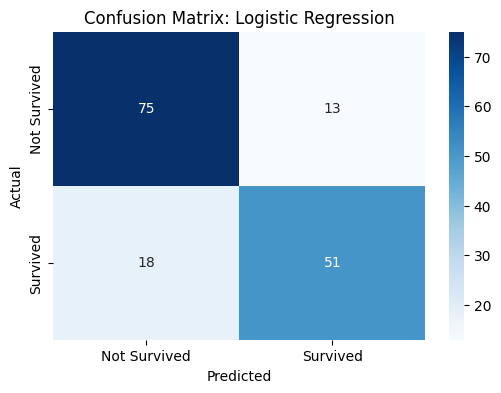

In [149]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix for the current Logistic Regression model (lr)
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

In [150]:
# Consolidated report for Logistic Regression
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        88
           1       0.80      0.74      0.77        69

    accuracy                           0.80       157
   macro avg       0.80      0.80      0.80       157
weighted avg       0.80      0.80      0.80       157



#### Support Vector Machine (SVM)

In [151]:
from sklearn.svm import SVC

# Short name for SVM
svm = SVC(random_state=42, probability=True)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc_svm:.4f}")

SVM Accuracy: 0.8153


In [152]:
# Evaluate SVM with more metrics
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f"SVM Precision: {precision_svm:.4f}")
print(f"SVM Recall: {recall_svm:.4f}")
print(f"SVM F1-Score: {f1_svm:.4f}")
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Precision: 0.8333
SVM Recall: 0.7246
SVM F1-Score: 0.7752

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84        88
           1       0.83      0.72      0.78        69

    accuracy                           0.82       157
   macro avg       0.82      0.81      0.81       157
weighted avg       0.82      0.82      0.81       157



### AUC-ROC Curve

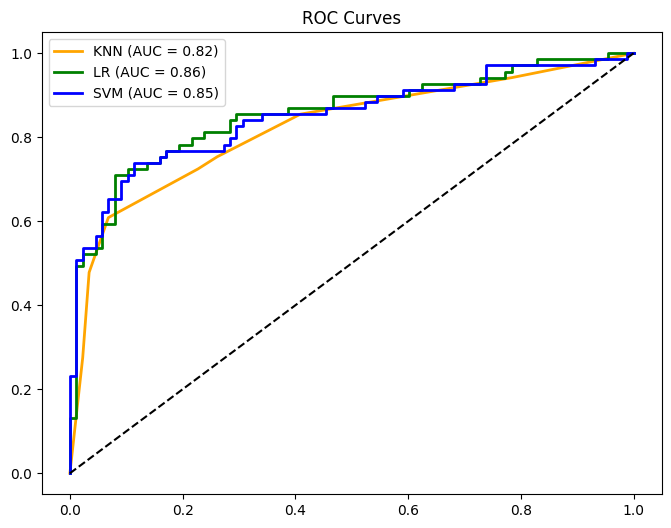

In [140]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Probabilities needed for ROC
prob_knn = knn.predict_proba(X_test_scaled)[:, 1]
prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

for prob, label, clr in zip([prob_knn, prob_lr, prob_svm], ['KNN', 'LR', 'SVM'], ['orange', 'green', 'blue']):
    fpr, tpr, _ = roc_curve(y_test, prob)
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=clr, lw=2, label=f'{label} (AUC = {score:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves')
plt.legend()
plt.show()